In [1]:
import os
import numpy as np
from PIL import Image
import pandas as pd
import matplotlib.pyplot as plt
import random
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import torch
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn
import seaborn as sns
from sklearn.metrics import roc_curve, auc

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Runtime -> Change runtime type -> Hardware accelerator -> GPU (-> Delete previous runtime -> OK).
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
  print("PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.")
  device = torch.device("cuda:0")
else:
  print("WARNING: PyTorch running on a CPU. See comment above to request a GPU instance.")
  device = torch.device("cpu")

PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.


In [4]:
base = "/content/drive/MyDrive/CS6140/project_data/38-Cloud_training"

folders = ["train_red", "train_green", "train_blue", "train_nir", "train_gt"]

for f in folders:
    path = os.path.join(base, f)
    if os.path.exists(path):
        print(f, ":", len(os.listdir(path)))
    else:
        print(f, ": folder missing")

train_red : 8400
train_green : 8400
train_blue : 8400
train_nir : 8400
train_gt : 8400


In [5]:
base = "/content/drive/MyDrive/CS6140/project_data/38-Cloud_test"
print(os.listdir(base))

['test_patches_38-Cloud.csv', 'test_sceneids_38-Cloud.csv', 'Entire_scene_gts', 'Natural_False_Color', 'test_blue', 'test_green', 'test_nir', 'test_red']


# Data exploration

training set:
- train_red, train_green, train_blue, train_nir
- train_gt (pixel-level cloud masks)

test set:
- same bands
- no patch level cloud masks
- has entire_scene_gts (scene level masks. more complex)


dataset is geared for semantic segmentation in deep learning. where models predict cloud masks and reconstruct full-scene outputs for evaluation.

But in this project, we reformulate the task as a patch-level classification problem by deriving labels from the provided ground-truth masks.


Dont know if i should use their test test. since its scene level masks.
Training set is for patch-level ML, the test set is full-scenes benchmarking.

But my problem is: patch -> label -> classification.
- i have inputs
- i have labels (gt)
- i will create the evaluation set

I will be splitting the data into train and test.

Next dilemma: separation of bands. Bands being separate is standard for remote sensing. How to turn them into inputs though.
for each patch, i have four grayscale images:
- red
- green
- blue
- nir
They all belong to the same patch. its one image with 4 channels.

instead of normal RGB shaped like: 384 x 384 x 3, it is 384 x 384 x 4



For CNN:
- stack the 4 bands together, and feed CNN 4-channel image


SVM and Random Forest:
- these models do not take images directly. They must be transformed into feature vectors.
- converting a 4-channel patch into a feature vector
- first, computing summary statistics for each band: mean, std, min, max
- 4 stats x 4 bands: 16 features per patch
-




# Data Exploration -  Setup

In [6]:
## your location for the training data
base = "/content/drive/MyDrive/CS6140/project_data/38-Cloud_training"

for folder in ["train_red", "train_green", "train_blue", "train_nir", "train_gt"]:
    files = sorted(os.listdir(os.path.join(base, folder)))
    print(folder, files[:3])

train_red ['red_patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'red_patch_100_5_by_12_LC08_L1TP_063016_20160920_20170221_01_T1.TIF', 'red_patch_100_5_by_12_LC08_L1TP_064014_20160420_20170223_01_T1.TIF']
train_green ['green_patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'green_patch_100_5_by_12_LC08_L1TP_063016_20160920_20170221_01_T1.TIF', 'green_patch_100_5_by_12_LC08_L1TP_064014_20160420_20170223_01_T1.TIF']
train_blue ['blue_patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'blue_patch_100_5_by_12_LC08_L1TP_063016_20160920_20170221_01_T1.TIF', 'blue_patch_100_5_by_12_LC08_L1TP_064014_20160420_20170223_01_T1.TIF']
train_nir ['nir_patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'nir_patch_100_5_by_12_LC08_L1TP_063016_20160920_20170221_01_T1.TIF', 'nir_patch_100_5_by_12_LC08_L1TP_064014_20160420_20170223_01_T1.TIF']
train_gt ['gt_patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'gt_patch_100_5_by_12_LC0

different prefixes for each band

In [7]:
def strip_prefix(fname):
    prefixes = ["red_", "green_", "blue_", "nir_", "gt_"]
    for p in prefixes:
        if fname.startswith(p):
            return fname[len(p):]
    return fname

folders = {
    "red": "train_red",
    "green": "train_green",
    "blue": "train_blue",
    "nir": "train_nir",
    "gt": "train_gt"
}

file_maps = {}
for key, folder in folders.items():
    folder_path = os.path.join(base, folder)
    files = os.listdir(folder_path)
    file_maps[key] = {strip_prefix(f): f for f in files}

common_ids = sorted(
    set(file_maps["red"])
    & set(file_maps["green"])
    & set(file_maps["blue"])
    & set(file_maps["nir"])
    & set(file_maps["gt"])
)

print("Common patch IDs:", len(common_ids))
print("First 3 IDs:", common_ids[:3])

Common patch IDs: 8400
First 3 IDs: ['patch_100_5_by_12_LC08_L1TP_061017_20160720_20170223_01_T1.TIF', 'patch_100_5_by_12_LC08_L1TP_063016_20160920_20170221_01_T1.TIF', 'patch_100_5_by_12_LC08_L1TP_064014_20160420_20170223_01_T1.TIF']


In [8]:
# only taking informative patches from dataset

csv_path = "/content/drive/MyDrive/CS6140/project_data/training_patches_38-cloud_nonempty.csv"
df = pd.read_csv(csv_path)
df.head()

,name
0,patch_100_5_by_12_LC08_L1TP_061017_20160720_20...
1,patch_100_5_by_12_LC08_L1TP_063016_20160920_20...
2,patch_100_5_by_12_LC08_L1TP_064014_20160420_20...
3,patch_100_5_by_12_LC08_L1TP_064017_20160420_20...
4,patch_100_5_by_12_LC08_L1TP_066017_20160520_20...


In [9]:
print(df.columns)

Index(['name'], dtype='object')


In [10]:
informative_ids = set(df["name"].astype(str).str.strip())

filtered_ids = [pid for pid in common_ids if pid.replace(".TIF", "") in informative_ids]

print("All aligned patches:", len(common_ids))
print("Informative aligned patches:", len(filtered_ids))

All aligned patches: 8400
Informative aligned patches: 5155


### load one patch

In [11]:
patch_id = common_ids[0]

red = np.array(Image.open(os.path.join(base, "train_red", file_maps["red"][patch_id])))
green = np.array(Image.open(os.path.join(base, "train_green", file_maps["green"][patch_id])))
blue = np.array(Image.open(os.path.join(base, "train_blue", file_maps["blue"][patch_id])))
nir = np.array(Image.open(os.path.join(base, "train_nir", file_maps["nir"][patch_id])))
mask = np.array(Image.open(os.path.join(base, "train_gt", file_maps["gt"][patch_id])))

print(red.shape, green.shape, blue.shape, nir.shape, mask.shape)

(384, 384) (384, 384) (384, 384) (384, 384) (384, 384)


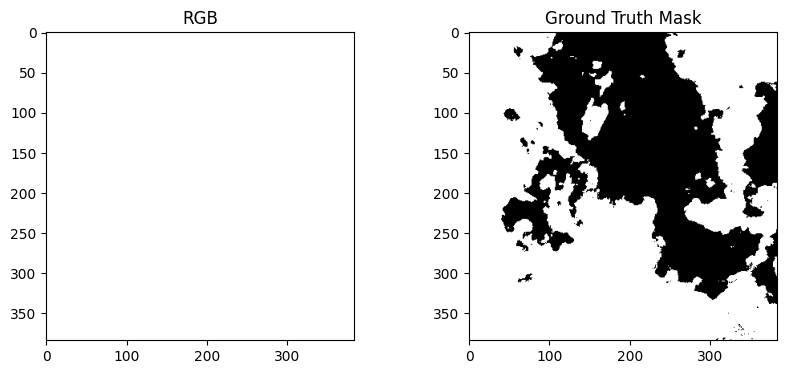

In [12]:
img = np.stack([red, green, blue, nir], axis=-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(img[:, :, :3])
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")

plt.show()

In [13]:
print("Red unique:", np.unique(red)[:10])
print("Green unique:", np.unique(green)[:10])
print("Blue unique:", np.unique(blue)[:10])

Red unique: [6354 6369 6379 6382 6386 6389 6393 6394 6395 6396]
Green unique: [7138 7141 7143 7144 7147 7148 7150 7151 7152 7153]
Blue unique: [8335 8361 8366 8367 8368 8370 8371 8375 8377 8379]


patch is not empty. just need to preprocess the data to see the channel correctly.


in remote sensing, they use normalization. Find the percentile bounds instead of min and max. Do this to ignore extreme dark and bright outliers.

basically clipping. then shift everything. - "Stretch/Cut: Use a Cumulative Count Cut (e.g., 3% to 97%) to ignore extreme outliers and improve contrast."

refer to this to why we did this: https://servir-amazonia.github.io/barbados-training/intro-to-remote-sensing/data-viz-landsat.html#:~:text=Go%20to%20%E2%80%9CPlugins%20%3E%20Cloud%20masking,as%20a%20true%20color%20image.

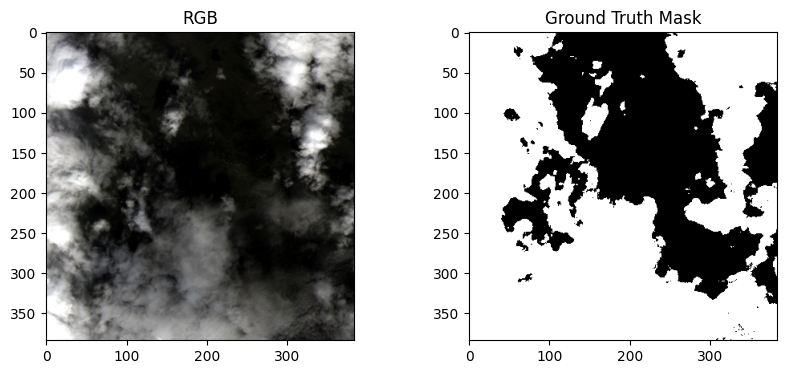

In [14]:
def normalize_percentile(band, lower=2, upper=98):
    band = band.astype(np.float32)
    low = np.percentile(band, lower)
    high = np.percentile(band, upper)
    band = np.clip(band, low, high)
    return (band - low) / (high - low + 1e-8)

rgb_display = np.stack([
    normalize_percentile(red),
    normalize_percentile(green),
    normalize_percentile(blue)
], axis=-1)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb_display)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(mask, cmap="gray")
plt.title("Ground Truth Mask")

plt.show()

## comparing full dataset vs filtered dataset: looking to filter out empty patches

In [15]:
# patch ID mapping

def load_patch(patch_id, base, file_maps):
    red = np.array(Image.open(os.path.join(base, "train_red", file_maps["red"][patch_id]))).astype(np.float32)
    green = np.array(Image.open(os.path.join(base, "train_green", file_maps["green"][patch_id]))).astype(np.float32)
    blue = np.array(Image.open(os.path.join(base, "train_blue", file_maps["blue"][patch_id]))).astype(np.float32)
    nir = np.array(Image.open(os.path.join(base, "train_nir", file_maps["nir"][patch_id]))).astype(np.float32)
    mask = np.array(Image.open(os.path.join(base, "train_gt", file_maps["gt"][patch_id])))

    return red, green, blue, nir, mask

red, green, blue, nir, mask = load_patch(filtered_ids[0], base, file_maps)
print(red.shape, green.shape, blue.shape, nir.shape, mask.shape)

(384, 384) (384, 384) (384, 384) (384, 384) (384, 384)


In [17]:
def is_empty_patch(red, green, blue, nir):
    return (
        red.max() == 0 and
        green.max() == 0 and
        blue.max() == 0 and
        nir.max() == 0
    )


def count_empty_patches(patch_ids, n=None):
    empty_flags = []

    ids = patch_ids if n is None else patch_ids[:n]

    for patch_id in ids:
        red, green, blue, nir, mask = load_patch(patch_id, base, file_maps)
        empty_flags.append(is_empty_patch(red, green, blue, nir))

    empty_flags = np.array(empty_flags)
    return empty_flags

In [18]:
common_empty = count_empty_patches(common_ids, 300)
filtered_empty = count_empty_patches(filtered_ids, 300)

print("All patches - empty:", np.sum(common_empty), "out of", len(common_empty))
print("Filtered patches - empty:", np.sum(filtered_empty), "out of", len(filtered_empty))

All patches - empty: 95 out of 300
Filtered patches - empty: 0 out of 300


### subset code - only used this before running full dataset experiments

In [19]:
# using filtered ids
# random.seed(42)

# sample_ids = random.sample(filtered_ids, 1500)

# Model 1: Random Forest

In [20]:
def get_binary_label(mask, threshold=0.2):
    frac = np.mean(mask > 0)
    return 1 if frac >= threshold else 0

# later for customizing cloud coverage task
def get_cloud_fraction(mask):
    return np.mean(mask > 0)


def get_coverage_class(mask):
    frac = get_cloud_fraction(mask)
    if frac == 0:
        return 0   # clear
    elif frac < 0.5:
        return 1   # partial
    else:
        return 2   # heavy

### pre-processing

for each patch, we want input features from the 4 bands, and label from the ground-truth mask

### extract features (method 1): 4 stats x 4 bands = 16 features

In [21]:
def extract_features(red, green, blue, nir):
    features = []

    for band in [red, green, blue, nir]:
        band = band / 10000.0  # simple consistent scaling for model input. change later if needed
        features.extend([
            np.mean(band),
            np.std(band),
            np.min(band),
            np.max(band)
        ])

    return np.array(features, dtype=np.float32)

In [22]:
# # build full dataset from informative patches
# X = []
# y_binary = []
# used_ids = []

# for patch_id in filtered_ids:
#     red, green, blue, nir, mask = load_patch(patch_id, base, file_maps)

#     features = extract_features(red, green, blue, nir)
#     binary_label = get_binary_label(mask, threshold=0.5)

#     X.append(features)
#     y_binary.append(binary_label)
#     used_ids.append(patch_id)

# X = np.array(X, dtype=np.float32)
# y_binary = np.array(y_binary, dtype=np.int64)

# print("Feature matrix shape:", X.shape)
# print("Binary label shape:", y_binary.shape)
# print("No cloud:", np.sum(y_binary == 0))
# print("Cloud:", np.sum(y_binary == 1))

In [23]:
# training Random Forest
# X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
#     X, y_binary, used_ids,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_binary
# )

In [24]:
### SAVE EVERYTHING

# save_path = "/content/drive/MyDrive/CS6140/project_data/saved_sets/"

# np.savez(
#     save_path + "cloud_dataset_full_thres_0.5.npz",
#     X=X,
#     y=y_binary,
#     ids=np.array(used_ids),

#     X_train=X_train,
#     X_val=X_val,
#     y_train=y_train,
#     y_val=y_val,
#     ids_train=np.array(ids_train),
#     ids_val=np.array(ids_val)
# )

# print("Saved dataset successfully")

In [25]:
def build_feature_dataset(patch_ids, base, file_maps, feature_fn, threshold=0.2, progress_every=500):
  """
  put description here
  """
  X = []
  y_binary = []
  used_ids = []

  for i, patch_id in enumerate(patch_ids):
      red, green, blue, nir, mask = load_patch(patch_id, base, file_maps)

      features = feature_fn(red, green, blue, nir)
      binary_label = get_binary_label(mask, threshold=threshold)

      X.append(features)
      y_binary.append(binary_label)
      used_ids.append(patch_id)

      if progress_every is not None and (i + 1) % progress_every == 0:
          print(f"Processed {i + 1}/{len(patch_ids)} patches")

  X = np.array(X, dtype=np.float32)
  y_binary = np.array(y_binary, dtype=np.int64)
  used_ids = np.array(used_ids)

  print("Feature matrix shape:", X.shape)
  print("Binary label shape:", y_binary.shape)
  print("No cloud:", np.sum(y_binary == 0))
  print("Cloud:", np.sum(y_binary == 1))
  print("Cloud fraction:", np.mean(y_binary))

  return X, y_binary, used_ids

In [26]:
# original features, 20% threshold
# X_20, y_20, ids_20 = build_feature_dataset(
#     filtered_ids,
#     base,
#     file_maps,
#     feature_fn=extract_features,
#     threshold=0.2
# )

In [27]:
# X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
#     X_20,
#     y_20,
#     ids_20,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_20
# )

In [28]:
def save_dataset(save_path, filename, X, y, ids, X_train, X_val, y_train, y_val, ids_train, ids_val):
  """
  description
  """
  full_path = save_path + filename

  np.savez(
      full_path,
      X=X,
      y=y,
      ids=ids,
      X_train=X_train,
      X_val=X_val,
      y_train=y_train,
      y_val=y_val,
      ids_train=ids_train,
      ids_val=ids_val
  )

  print(f"Saved dataset to {full_path}")

In [29]:
# save_dataset(
#     save_path="/content/drive/MyDrive/CS6140/project_data/saved_sets/",
#     filename="cloud_dataset_orig_50.npz",

#     X=X_20,
#     y=y_20,
#     ids=ids_20,

#     X_train=X_train,
#     X_val=X_val,
#     y_train=y_train,
#     y_val=y_val,

#     ids_train=ids_train,
#     ids_val=ids_val
# )

## choose which built dataset to load in

In [30]:
def load_dataset(file_path):
    data = np.load(file_path, allow_pickle=True)

    dataset = {
        "X": data["X"],
        "y": data["y"],
        "ids": data["ids"],

        "X_train": data["X_train"],
        "X_val": data["X_val"],
        "y_train": data["y_train"],
        "y_val": data["y_val"],

        "ids_train": data["ids_train"],
        "ids_val": data["ids_val"]
    }

    num_no_cloud = np.sum(dataset["y"] == 0)
    num_cloud = np.sum(dataset["y"] == 1)
    total = len(dataset["y"])

    print(f"\nLoaded dataset from: {file_path}")
    print("Full dataset:", dataset["X"].shape, dataset["y"].shape)
    print("Train:", dataset["X_train"].shape)
    print("Val:", dataset["X_val"].shape)


    print("\nClass distribution (full dataset):")
    print(f"No cloud: {num_no_cloud} ({num_no_cloud/total:.2%})")
    print(f"Cloud: {num_cloud} ({num_cloud/total:.2%})")

    return dataset

## Random Forest Model 1:  Stat Features

In [31]:
data_20 = load_dataset("/content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_thres_0.2.npz")

X = data_20["X"]
y = data_20["y"]

X_train = data_20["X_train"]
X_val = data_20["X_val"]
y_train = data_20["y_train"]
y_val = data_20["y_val"]


Loaded dataset from: /content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_thres_0.2.npz
Full dataset: (5155, 16) (5155,)
Train: (4124, 16)
Val: (1031, 16)

Class distribution (full dataset):
No cloud: 1749 (33.93%)
Cloud: 3406 (66.07%)


In [32]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))

Validation accuracy: 0.930164888457808

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       350
           1       0.94      0.95      0.95       681

    accuracy                           0.93      1031
   macro avg       0.92      0.92      0.92      1031
weighted avg       0.93      0.93      0.93      1031



In [33]:
# feature importance
feature_names = [
    "red_mean","red_std","red_min","red_max",
    "green_mean","green_std","green_min","green_max",
    "blue_mean","blue_std","blue_min","blue_max",
    "nir_mean","nir_std","nir_min","nir_max"
]

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_imp)

       feature  importance
15     nir_max    0.115474
8    blue_mean    0.098131
14     nir_min    0.075804
12    nir_mean    0.063119
4   green_mean    0.061789
9     blue_std    0.060712
7    green_max    0.059618
3      red_max    0.058425
0     red_mean    0.057955
13     nir_std    0.056492
1      red_std    0.055592
11    blue_max    0.054352
5    green_std    0.050843
10    blue_min    0.047939
2      red_min    0.044926
6    green_min    0.038829


In [34]:
train_pred = rf.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Val accuracy:", accuracy_score(y_val, y_pred))

Train accuracy: 1.0
Val accuracy: 0.930164888457808


Train >> val, overfitting a bit.

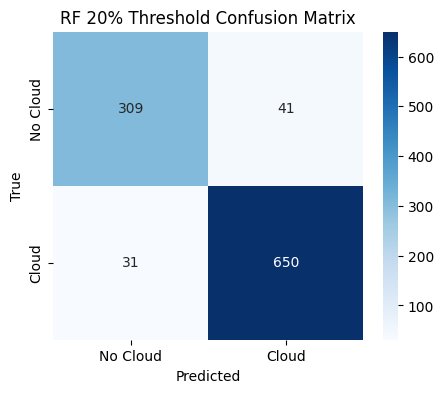

In [35]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Cloud", "Cloud"],
            yticklabels=["No Cloud", "Cloud"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF 20% Threshold Confusion Matrix")
plt.show()

confusing some clear patches as cloud.

slightly biased toward cloud.

### considering the moderate class imbalance

In [36]:
# method 1: using class_weight parameter

rf = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))

Validation accuracy: 0.9282250242483027

Classification report:
              precision    recall  f1-score   support

           0       0.90      0.89      0.89       350
           1       0.94      0.95      0.95       681

    accuracy                           0.93      1031
   macro avg       0.92      0.92      0.92      1031
weighted avg       0.93      0.93      0.93      1031



In [37]:
# feature importance
feature_names = [
    "red_mean","red_std","red_min","red_max",
    "green_mean","green_std","green_min","green_max",
    "blue_mean","blue_std","blue_min","blue_max",
    "nir_mean","nir_std","nir_min","nir_max"
]

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_imp)

       feature  importance
15     nir_max    0.122073
8    blue_mean    0.100842
14     nir_min    0.094952
12    nir_mean    0.063757
3      red_max    0.059966
9     blue_std    0.058584
13     nir_std    0.058001
4   green_mean    0.057830
0     red_mean    0.056241
1      red_std    0.053033
7    green_max    0.051918
5    green_std    0.048524
10    blue_min    0.046963
2      red_min    0.044342
6    green_min    0.041769
11    blue_max    0.041205


In [38]:
train_pred = rf.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Val accuracy:", accuracy_score(y_val, y_pred))

Train accuracy: 1.0
Val accuracy: 0.9282250242483027


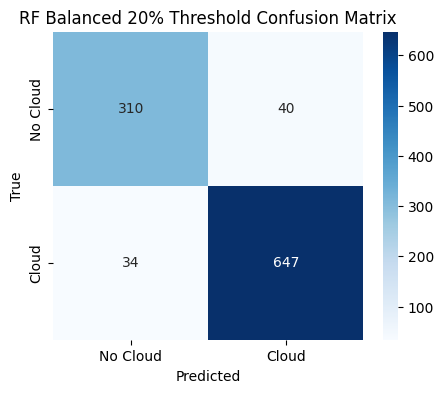

In [39]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Cloud", "Cloud"],
            yticklabels=["No Cloud", "Cloud"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("RF Balanced 20% Threshold Confusion Matrix")
plt.show()

Use it as a tuning parameter.

### hyper-parameter tuning - grid search

- n_estimators
- max_depth
- min_samples_leaf
- class_weight

In [40]:
rf_results = []

for cw in [None, "balanced"]:
    for n_estimators in [100, 300]:
        for max_depth in [None, 10, 20]:
            for min_samples_leaf in [1, 5]:

                rf = RandomForestClassifier(
                    n_estimators=n_estimators,
                    max_depth=max_depth,
                    min_samples_leaf=min_samples_leaf,
                    class_weight=cw,
                    random_state=42,
                    n_jobs=-1
                )

                rf.fit(X_train, y_train)

                train_pred = rf.predict(X_train)
                val_pred = rf.predict(X_val)

                train_acc = accuracy_score(y_train, train_pred)
                val_acc = accuracy_score(y_val, val_pred)
                gap = train_acc - val_acc

                rf_results.append({
                    "class_weight": cw,
                    "n_estimators": n_estimators,
                    "max_depth": max_depth,
                    "min_samples_leaf": min_samples_leaf,
                    "train_accuracy": train_acc,
                    "val_accuracy": val_acc,
                    "gap": gap
                })

                print(
                    f"class_weight={cw}, "
                    f"n_estimators={n_estimators}, "
                    f"max_depth={max_depth}, "
                    f"min_samples_leaf={min_samples_leaf}, "
                    f"train_acc={train_acc:.4f}, "
                    f"val_acc={val_acc:.4f}, "
                    f"gap={gap:.4f}"
                )

rf_results_df = pd.DataFrame(rf_results).sort_values(
    by=["gap", "val_accuracy"],
    ascending=[True, False]
)

print("\nSorted RF results:")
print(rf_results_df)

class_weight=None, n_estimators=100, max_depth=None, min_samples_leaf=1, train_acc=1.0000, val_acc=0.9302, gap=0.0698
class_weight=None, n_estimators=100, max_depth=None, min_samples_leaf=5, train_acc=0.9634, val_acc=0.9214, gap=0.0419
class_weight=None, n_estimators=100, max_depth=10, min_samples_leaf=1, train_acc=0.9748, val_acc=0.9195, gap=0.0553
class_weight=None, n_estimators=100, max_depth=10, min_samples_leaf=5, train_acc=0.9476, val_acc=0.9176, gap=0.0301
class_weight=None, n_estimators=100, max_depth=20, min_samples_leaf=1, train_acc=1.0000, val_acc=0.9292, gap=0.0708
class_weight=None, n_estimators=100, max_depth=20, min_samples_leaf=5, train_acc=0.9634, val_acc=0.9214, gap=0.0419
class_weight=None, n_estimators=300, max_depth=None, min_samples_leaf=1, train_acc=1.0000, val_acc=0.9302, gap=0.0698
class_weight=None, n_estimators=300, max_depth=None, min_samples_leaf=5, train_acc=0.9658, val_acc=0.9263, gap=0.0395
class_weight=None, n_estimators=300, max_depth=10, min_samples_l

looking for the hyper parameter tuning with the least gap.


overfitting:
- max_depth = None
- min_samples_leaf = 1
- train = 1.00, val = 0.93
- train >> val
- this was our baseline

when we increase min_samples_leaf from 1 to 5:
- gap starts to close
- train  = 0.9634, val = 0.9214

depth constraint:
- increasing depth decreases training accuracy, but also decreases val accuracy as well. so decreases both. gap doesnt decrease, both accuracies just decrease

increasing max_estimators:
- no real gain
- results very similar
- can create more stability across runs to increase.

class_weight = balanced:
- did not see improvement



two candidates:
- least gap, with good performance:
- n_estimators = 300
- Max_depth = None
- min_samples_leaf = 6
- class_weight = Balance

- best validation accuracy, still small gap
- everythin the same, but n_samples_leaf = 1, and max_depth = None


### Best RF Model:

Compare two models.

model 1:
- n_estimators = 300
- Max_depth = 10
- min_samples_leaf = 5

model 2:
- n_estimators = 300
- max_depth = None
- min_samples_leaf = 1

In [41]:
# best rf tuning
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight = None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred))


Validation accuracy: 0.9194956353055286

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.84      0.88       350
           1       0.92      0.96      0.94       681

    accuracy                           0.92      1031
   macro avg       0.92      0.90      0.91      1031
weighted avg       0.92      0.92      0.92      1031


Confusion matrix:
[[294  56]
 [ 27 654]]


### cross-validation on best model

In [42]:
rf_final = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    class_weight = "balanced",
    random_state=42
)

scores = cross_val_score(
    rf_final,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

CV scores: [0.88166828 0.91949564 0.90494665 0.88360815 0.83511154]
Mean CV accuracy: 0.8849660523763335
Std: 0.028599677973202113


In [43]:
# model with better val accuracy, a little less closed gap
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight = None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred))




Validation accuracy: 0.930164888457808

Classification report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.90       350
           1       0.94      0.95      0.95       681

    accuracy                           0.93      1031
   macro avg       0.92      0.92      0.92      1031
weighted avg       0.93      0.93      0.93      1031


Confusion matrix:
[[309  41]
 [ 31 650]]


In [44]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

CV scores: [0.8942774  0.93792435 0.91270611 0.90009699 0.86129971]
Mean CV accuracy: 0.9012609117361784
Std: 0.024988884703603716


In [45]:
# feature importance
feature_names = [
    "red_mean","red_std","red_min","red_max",
    "green_mean","green_std","green_min","green_max",
    "blue_mean","blue_std","blue_min","blue_max",
    "nir_mean","nir_std","nir_min","nir_max"
]

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_imp)


       feature  importance
15     nir_max    0.116825
8    blue_mean    0.100342
14     nir_min    0.078172
4   green_mean    0.063439
12    nir_mean    0.062994
9     blue_std    0.062578
7    green_max    0.059864
0     red_mean    0.057964
3      red_max    0.057795
13     nir_std    0.056890
1      red_std    0.054033
11    blue_max    0.051995
5    green_std    0.047785
10    blue_min    0.046551
2      red_min    0.043240
6    green_min    0.039534


BEST model:
- n_estimators = 300
- max_depth = None
- min_samples_leaf = 1

## Random Forest Model 2: Two additional features

In [46]:
## adding NDVI and brightness
def extract_features_2(red, green, blue, nir):
    features = []

    # normalize bands (0-1)
    red = red / 10000.0
    green = green / 10000.0
    blue = blue / 10000.0
    nir = nir / 10000.0

    # basic statistics for each band
    for band in [red, green, blue, nir]:
        features.extend([
            np.mean(band),
            np.std(band),
            np.min(band),
            np.max(band)
        ])

    # brightness. visible bands only
    brightness = (red + green + blue) / 3
    features.extend([
        np.mean(brightness),
        np.std(brightness)
    ])

    # ndvi
    ndvi = (nir - red) / (nir + red + 1e-8)  # avoid divide by zero
    features.extend([
        np.mean(ndvi),
        np.std(ndvi)
    ])

    return features

In [47]:
# additional features, 20% threshold
# X_20_new_feat, y_20_new_feat, ids_20_new_feat = build_feature_dataset(
#     filtered_ids,
#     base,
#     file_maps,
#     feature_fn=extract_features,
#     threshold=0.2
# )

In [48]:
# X_train, X_val, y_train, y_val, ids_train, ids_val = train_test_split(
#     X_20_new_feat,
#     y_20_new_feat,
#     ids_20_new_feat,
#     test_size=0.2,
#     random_state=42,
#     stratify=y_20
# )

In [49]:
# save_dataset(
#     save_path="/content/drive/MyDrive/CS6140/project_data/saved_sets/",
#     filename="cloud_dataset_full_new_features_0.2.npz",

#     X=X_20_new_feat,
#     y=y_20_new_feat,
#     ids=ids_20_new_feat,

#     X_train=X_train,
#     X_val=X_val,
#     y_train=y_train,
#     y_val=y_val,

#     ids_train=ids_train,
#     ids_val=ids_val
# )

In [50]:
# load in dataset
data_20_new_feat = load_dataset("/content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_new_features_0.2.npz")

X = data_20_new_feat["X"]
y = data_20_new_feat["y"]

X_train = data_20_new_feat["X_train"]
X_val = data_20_new_feat["X_val"]
y_train = data_20_new_feat["y_train"]
y_val = data_20_new_feat["y_val"]


Loaded dataset from: /content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_new_features_0.2.npz
Full dataset: (5155, 20) (5155,)
Train: (4124, 20)
Val: (1031, 20)

Class distribution (full dataset):
No cloud: 1749 (33.93%)
Cloud: 3406 (66.07%)


In [51]:
print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

print("No cloud:", np.sum(y == 0))
print("Cloud:", np.sum(y == 1))

print("Cloud fraction:", np.mean(y))

Feature matrix shape: (5155, 20)
Label shape: (5155,)
No cloud: 1749
Cloud: 3406
Cloud fraction: 0.660717749757517


In [52]:
# baseline model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred))

Validation accuracy: 0.9359844810863239

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       350
           1       0.95      0.96      0.95       681

    accuracy                           0.94      1031
   macro avg       0.93      0.93      0.93      1031
weighted avg       0.94      0.94      0.94      1031


Confusion matrix:
[[312  38]
 [ 28 653]]


In [53]:
train_pred = rf.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Val accuracy:", accuracy_score(y_val, y_pred))

Train accuracy: 1.0
Val accuracy: 0.9359844810863239


In [54]:
feature_names = [
    "red_mean","red_std","red_min","red_max",
    "green_mean","green_std","green_min","green_max",
    "blue_mean","blue_std","blue_min","blue_max",
    "nir_mean","nir_std","nir_min","nir_max",
    "brightness_mean","brightness_std",
    "ndvi_mean","ndvi_std"
]

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_imp)

            feature  importance
18        ndvi_mean    0.140628
8         blue_mean    0.076809
19         ndvi_std    0.076432
15          nir_max    0.068868
14          nir_min    0.062580
16  brightness_mean    0.052429
0          red_mean    0.045325
4        green_mean    0.040991
9          blue_std    0.040511
7         green_max    0.040455
5         green_std    0.039910
3           red_max    0.039837
12         nir_mean    0.038587
11         blue_max    0.036740
13          nir_std    0.035968
10         blue_min    0.034709
1           red_std    0.034606
17   brightness_std    0.033525
2           red_min    0.031795
6         green_min    0.029295


In [55]:
## best model
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight=None,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_val)

print("Validation accuracy:", accuracy_score(y_val, y_pred))
print("\nClassification report:")
print(classification_report(y_val, y_pred))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred))

Validation accuracy: 0.9350145489815713

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.89      0.90       350
           1       0.94      0.96      0.95       681

    accuracy                           0.94      1031
   macro avg       0.93      0.92      0.93      1031
weighted avg       0.93      0.94      0.93      1031


Confusion matrix:
[[311  39]
 [ 28 653]]


In [56]:
train_pred = rf.predict(X_train)
print("Train accuracy:", accuracy_score(y_train, train_pred))
print("Val accuracy:", accuracy_score(y_val, y_pred))

Train accuracy: 1.0
Val accuracy: 0.9350145489815713


In [57]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", scores)
print("Mean CV accuracy:", scores.mean())
print("Std:", scores.std())

CV scores: [0.89815713 0.93986421 0.91658584 0.91076625 0.8700291 ]
Mean CV accuracy: 0.9070805043646943
Std: 0.022939663238167998


In [58]:
feature_names = [
    "red_mean","red_std","red_min","red_max",
    "green_mean","green_std","green_min","green_max",
    "blue_mean","blue_std","blue_min","blue_max",
    "nir_mean","nir_std","nir_min","nir_max",
    "brightness_mean","brightness_std",
    "ndvi_mean","ndvi_std"
]

importances = rf.feature_importances_

df_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print(df_imp)

            feature  importance
18        ndvi_mean    0.138814
8         blue_mean    0.078035
15          nir_max    0.073064
19         ndvi_std    0.070713
14          nir_min    0.059821
16  brightness_mean    0.053892
4        green_mean    0.044932
12         nir_mean    0.042380
0          red_mean    0.041541
7         green_max    0.041527
3           red_max    0.041456
9          blue_std    0.040088
13          nir_std    0.038201
1           red_std    0.036464
11         blue_max    0.036416
5         green_std    0.035331
17   brightness_std    0.034271
2           red_min    0.032252
10         blue_min    0.031392
6         green_min    0.029410


# Model 2: SVM

## SVM Model 1: stat features

In [59]:
data_20 = load_dataset("/content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_thres_0.2.npz")

X = data_20["X"]
y = data_20["y"]

X_train = data_20["X_train"]
X_val = data_20["X_val"]
y_train = data_20["y_train"]
y_val = data_20["y_val"]


Loaded dataset from: /content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_thres_0.2.npz
Full dataset: (5155, 16) (5155,)
Train: (4124, 16)
Val: (1031, 16)

Class distribution (full dataset):
No cloud: 1749 (33.93%)
Cloud: 3406 (66.07%)


In [60]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

print("SVM accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_val, y_pred_svm))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred_svm))

SVM accuracy: 0.8884578079534433

Classification report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       350
           1       0.90      0.94      0.92       681

    accuracy                           0.89      1031
   macro avg       0.88      0.86      0.87      1031
weighted avg       0.89      0.89      0.89      1031


Confusion matrix:
[[275  75]
 [ 40 641]]


### hyper parameter tuning: SVM

In [61]:
# comparing kernels

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

kernels = ['linear', 'rbf', 'poly']

for k in kernels:
    model = SVC(kernel=k)
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_val_scaled)

    acc = accuracy_score(y_val, preds)
    print(f"{k} kernel accuracy:", acc)

linear kernel accuracy: 0.8050436469447139
rbf kernel accuracy: 0.8884578079534433
poly kernel accuracy: 0.8157129000969933


RBF does best.

In [62]:
# regularizatoin
c_results = []

for C in [0.1, 1, 10]:
    svm = make_pipeline(StandardScaler(), SVC(kernel="rbf", C=C))
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_val)

    acc = accuracy_score(y_val, y_pred)

    c_results.append({
        "C": C,
        "accuracy": acc
    })

    print(f"\nRBF kernel, C={C}")
    print("Accuracy:", acc)
    print(classification_report(y_val, y_pred))
    print(confusion_matrix(y_val, y_pred))


RBF kernel, C=0.1
Accuracy: 0.8322017458777885
              precision    recall  f1-score   support

           0       0.86      0.60      0.71       350
           1       0.82      0.95      0.88       681

    accuracy                           0.83      1031
   macro avg       0.84      0.78      0.80      1031
weighted avg       0.84      0.83      0.82      1031

[[210 140]
 [ 33 648]]

RBF kernel, C=1
Accuracy: 0.8884578079534433
              precision    recall  f1-score   support

           0       0.87      0.79      0.83       350
           1       0.90      0.94      0.92       681

    accuracy                           0.89      1031
   macro avg       0.88      0.86      0.87      1031
weighted avg       0.89      0.89      0.89      1031

[[275  75]
 [ 40 641]]

RBF kernel, C=10
Accuracy: 0.9243452958292919
              precision    recall  f1-score   support

           0       0.91      0.87      0.89       350
           1       0.93      0.95      0.94       

In [63]:
# gamma hyperparameter
configs = [
    (10, 0.1),
    (1, 1),
    (10, "scale")
]

for C, gamma in configs:
    svm = make_pipeline(
        StandardScaler(),
        SVC(kernel="rbf", C=C, gamma=gamma)
    )

    svm.fit(X_train, y_train)
    preds = svm.predict(X_val)

    print(f"\nC={C}, gamma={gamma}")
    print("Accuracy:", accuracy_score(y_val, preds))
    print("Confusion Matrix:")
    print(confusion_matrix(y_val, preds))
    print("Classification Report:")
    print(classification_report(y_val, preds))


C=10, gamma=0.1
Accuracy: 0.9398642095053347
Confusion Matrix:
[[317  33]
 [ 29 652]]
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       350
           1       0.95      0.96      0.95       681

    accuracy                           0.94      1031
   macro avg       0.93      0.93      0.93      1031
weighted avg       0.94      0.94      0.94      1031


C=1, gamma=1
Accuracy: 0.9350145489815713
Confusion Matrix:
[[307  43]
 [ 24 657]]
Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.88      0.90       350
           1       0.94      0.96      0.95       681

    accuracy                           0.94      1031
   macro avg       0.93      0.92      0.93      1031
weighted avg       0.93      0.94      0.93      1031


C=10, gamma=scale
Accuracy: 0.9243452958292919
Confusion Matrix:
[[303  47]
 [ 31 650]]
Classification Report:
              pre

In [64]:
# best architecture

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

svm = SVC(kernel = "rbf", C=10, gamma=0.1)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

print("SVM accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_val, y_pred_svm))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred_svm))



SVM accuracy: 0.9398642095053347

Classification report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       350
           1       0.95      0.96      0.95       681

    accuracy                           0.94      1031
   macro avg       0.93      0.93      0.93      1031
weighted avg       0.94      0.94      0.94      1031


Confusion matrix:
[[317  33]
 [ 29 652]]


In [65]:
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma=0.1)
)

cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

CV scores: [0.90397672 0.94083414 0.91561591 0.92046557 0.87778855]
Mean CV accuracy: 0.9117361784675072
Std: 0.020739316796747384


### class_weight = balanced with best model

In [66]:
svm_balanced = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma=0.1, class_weight="balanced")
)

svm_balanced.fit(X_train, y_train)
preds = svm_balanced.predict(X_val)

print("Accuracy:", accuracy_score(y_val, preds))
print(confusion_matrix(y_val, preds))
print(classification_report(y_val, preds))

Accuracy: 0.9350145489815713
[[336  14]
 [ 53 628]]
              precision    recall  f1-score   support

           0       0.86      0.96      0.91       350
           1       0.98      0.92      0.95       681

    accuracy                           0.94      1031
   macro avg       0.92      0.94      0.93      1031
weighted avg       0.94      0.94      0.94      1031



## SVM Model 2: two new features

In [67]:
# load in dataset
data_20_new_feat = load_dataset("/content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_new_features_0.2.npz")

X = data_20_new_feat["X"]
y = data_20_new_feat["y"]

X_train = data_20_new_feat["X_train"]
X_val = data_20_new_feat["X_val"]
y_train = data_20_new_feat["y_train"]
y_val = data_20_new_feat["y_val"]


Loaded dataset from: /content/drive/MyDrive/CS6140/project_data/saved_sets/cloud_dataset_full_new_features_0.2.npz
Full dataset: (5155, 20) (5155,)
Train: (4124, 20)
Val: (1031, 20)

Class distribution (full dataset):
No cloud: 1749 (33.93%)
Cloud: 3406 (66.07%)


In [68]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

svm = SVC()
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

print("SVM accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_val, y_pred_svm))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred_svm))

SVM accuracy: 0.9030067895247332

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.81      0.85       350
           1       0.91      0.95      0.93       681

    accuracy                           0.90      1031
   macro avg       0.90      0.88      0.89      1031
weighted avg       0.90      0.90      0.90      1031


Confusion matrix:
[[284  66]
 [ 34 647]]


In [69]:
# best architecture

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_val_scaled = scaler.transform(X_val)

svm = SVC(kernel = "rbf", C=10, gamma=0.1)
svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_val_scaled)

print("SVM accuracy:", accuracy_score(y_val, y_pred_svm))
print("\nClassification report:")
print(classification_report(y_val, y_pred_svm))
print("\nConfusion matrix:")
print(confusion_matrix(y_val, y_pred_svm))


SVM accuracy: 0.9476236663433559

Classification report:
              precision    recall  f1-score   support

           0       0.93      0.92      0.92       350
           1       0.96      0.96      0.96       681

    accuracy                           0.95      1031
   macro avg       0.94      0.94      0.94      1031
weighted avg       0.95      0.95      0.95      1031


Confusion matrix:
[[322  28]
 [ 26 655]]


In [70]:
svm_pipeline = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", C=10, gamma=0.1)
)

cv_scores = cross_val_score(
    svm_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("CV scores:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std:", np.std(cv_scores))

CV scores: [0.92240543 0.94956353 0.92046557 0.92240543 0.88942774]
Mean CV accuracy: 0.9208535402521824
Std: 0.019062065562038003


# Model 3: Deep-CNN

In [71]:
# image loader

def load_patch_image(patch_id, base, file_maps):
  red = np.array(Image.open(os.path.join(base, "train_red", file_maps["red"][patch_id]))).astype(np.float32) / 10000.0
  green = np.array(Image.open(os.path.join(base, "train_green", file_maps["green"][patch_id]))).astype(np.float32) / 10000.0
  blue = np.array(Image.open(os.path.join(base, "train_blue", file_maps["blue"][patch_id]))).astype(np.float32) / 10000.0
  nir = np.array(Image.open(os.path.join(base, "train_nir", file_maps["nir"][patch_id]))).astype(np.float32) / 10000.0
  mask = np.array(Image.open(os.path.join(base, "train_gt", file_maps["gt"][patch_id])))

  image = np.stack([red, green, blue, nir], axis=0)
  return image, mask

In [72]:
def build_cnn_dataset(filtered_ids, base, file_maps, threshold=0.2):
    X_img = []
    y_img = []
    used_ids_img = []

    for i, patch_id in enumerate(filtered_ids):
        image, mask = load_patch_image(patch_id, base, file_maps)
        binary_label = get_binary_label(mask, threshold=threshold)

        X_img.append(image)
        y_img.append(binary_label)
        used_ids_img.append(patch_id)

        if (i + 1) % 500 == 0:
            print(f"Processed {i+1}/{len(filtered_ids)} patches")

    X_img = np.array(X_img, dtype=np.float32)
    y_img = np.array(y_img, dtype=np.int64)
    used_ids_img = np.array(used_ids_img)

    print("\nDataset summary:")
    print("Image tensor shape:", X_img.shape)
    print("Label shape:", y_img.shape)
    print("No cloud:", np.sum(y_img == 0))
    print("Cloud:", np.sum(y_img == 1))

    return X_img, y_img, used_ids_img


In [73]:
# X_img_20, y_img_20, ids_20 = build_cnn_dataset(
#     filtered_ids, base, file_maps, threshold=0.2
# )

In [74]:
# saved in my drive
# np.savez("/content/drive/MyDrive/CS6140/project_data/saved_sets/cnn_dataset_20.npz",
#          X=X_img_20, y=y_img_20, ids=ids_20)

### load in cnn-built dataset


In [75]:
data = np.load("/content/drive/MyDrive/CS6140/project_data/saved_sets/cnn_dataset_20.npz")

X_img_20 = data["X"]
y_img_20 = data["y"]
ids_20 = data["ids"]

print("Loaded shapes:", X_img_20.shape, y_img_20.shape)

Loaded shapes: (5155, 4, 384, 384) (5155,)


In [76]:
# split full CNN dataset
X_train_img, X_val_img, y_train_img, y_val_img, ids_train_img, ids_val_img = train_test_split(
    X_img_20,
    y_img_20,
    ids_20,
    test_size=0.2,
    random_state=42,
    stratify=y_img_20
)

print("Train shape:", X_train_img.shape, y_train_img.shape)
print("Val shape:", X_val_img.shape, y_val_img.shape)

Train shape: (4124, 4, 384, 384) (4124,)
Val shape: (1031, 4, 384, 384) (1031,)


In [77]:
# building dataloaders

train_dataset = TensorDataset(
    torch.tensor(X_train_img, dtype=torch.float32),
    torch.tensor(y_train_img, dtype=torch.long)
)

val_dataset = TensorDataset(
    torch.tensor(X_val_img, dtype=torch.float32),
    torch.tensor(y_val_img, dtype=torch.long)
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

In [78]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 48 * 48, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [79]:
class DropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 48 * 48, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [80]:
# Runtime -> Change runtime type -> Hardware accelerator -> GPU (-> Delete previous runtime -> OK).
if torch.cuda.is_available() and torch.cuda.device_count() > 0:
  print("PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.")
  device = torch.device("cuda:0")
else:
  print("WARNING: PyTorch running on a CPU. See comment above to request a GPU instance.")
  device = torch.device("cpu")

PyTorch running on a GPU. Use '.to(device)' to move tensors and models to GPU.


In [81]:
def train_model(model, train_loader, val_loader, epochs, lr, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        # TRAIN
        model.train()
        running_loss, correct, total = 0, 0, 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

        train_loss = running_loss / total
        train_acc = correct / total

        # VALIDATION
        model.eval()
        running_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)

                running_loss += loss.item() * images.size(0)
                _, preds = torch.max(outputs, 1)
                correct += (preds == labels).sum().item()
                total += labels.size(0)

        val_loss = running_loss / total
        val_acc = correct / total

        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"  Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

    return train_losses, val_losses, train_accs, val_accs

In [82]:
model = SimpleCNN().to(device)

train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.001,
    device=device
)

Epoch 1/10
  Train Loss: 0.6046 | Train Acc: 0.7274
  Val   Loss: 0.4152 | Val   Acc: 0.8050
Epoch 2/10
  Train Loss: 0.4002 | Train Acc: 0.8164
  Val   Loss: 0.3572 | Val   Acc: 0.8526
Epoch 3/10
  Train Loss: 0.3124 | Train Acc: 0.8708
  Val   Loss: 0.2306 | Val   Acc: 0.9069
Epoch 4/10
  Train Loss: 0.2842 | Train Acc: 0.8843
  Val   Loss: 0.5336 | Val   Acc: 0.7740
Epoch 5/10
  Train Loss: 0.2669 | Train Acc: 0.8911
  Val   Loss: 0.3125 | Val   Acc: 0.8855
Epoch 6/10
  Train Loss: 0.1893 | Train Acc: 0.9219
  Val   Loss: 0.3726 | Val   Acc: 0.8710
Epoch 7/10
  Train Loss: 0.1787 | Train Acc: 0.9285
  Val   Loss: 0.5844 | Val   Acc: 0.8400
Epoch 8/10
  Train Loss: 0.1518 | Train Acc: 0.9425
  Val   Loss: 0.5255 | Val   Acc: 0.8574
Epoch 9/10
  Train Loss: 0.1370 | Train Acc: 0.9510
  Val   Loss: 0.5652 | Val   Acc: 0.8535
Epoch 10/10
  Train Loss: 0.1248 | Train Acc: 0.9571
  Val   Loss: 0.4910 | Val   Acc: 0.8865


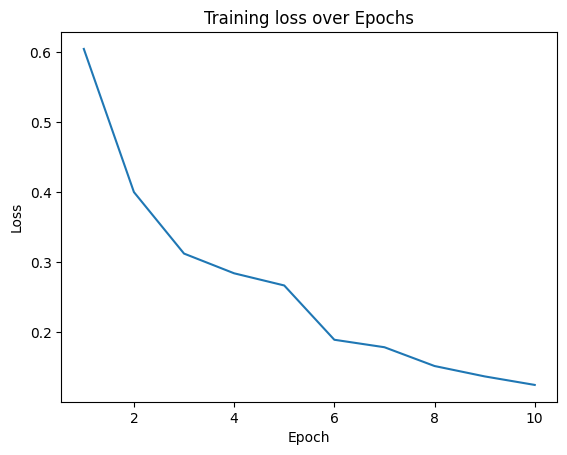

In [83]:
plt.plot(range(1, 11), train_losses, label="train")
plt.title( "Training loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

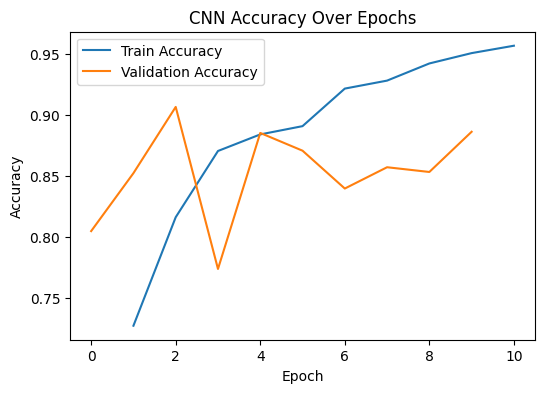

In [84]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Over Epochs")
plt.legend()
plt.show()

### analysis

Next step is to reduce learning rate. And then adding dropout for regularization.

In [85]:
## reducing learning rate.

model = SimpleCNN().to(device)

train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0001,
    device=device
)

Epoch 1/10
  Train Loss: 0.5341 | Train Acc: 0.7294
  Val   Loss: 0.4220 | Val   Acc: 0.7798
Epoch 2/10
  Train Loss: 0.3424 | Train Acc: 0.8516
  Val   Loss: 0.2807 | Val   Acc: 0.8758
Epoch 3/10
  Train Loss: 0.2789 | Train Acc: 0.8843
  Val   Loss: 0.3521 | Val   Acc: 0.8312
Epoch 4/10
  Train Loss: 0.2262 | Train Acc: 0.9054
  Val   Loss: 0.1976 | Val   Acc: 0.9234
Epoch 5/10
  Train Loss: 0.2061 | Train Acc: 0.9197
  Val   Loss: 0.2605 | Val   Acc: 0.8865
Epoch 6/10
  Train Loss: 0.1842 | Train Acc: 0.9306
  Val   Loss: 0.2956 | Val   Acc: 0.8778
Epoch 7/10
  Train Loss: 0.1483 | Train Acc: 0.9450
  Val   Loss: 0.2580 | Val   Acc: 0.9001
Epoch 8/10
  Train Loss: 0.1367 | Train Acc: 0.9481
  Val   Loss: 0.2028 | Val   Acc: 0.9253
Epoch 9/10
  Train Loss: 0.1245 | Train Acc: 0.9551
  Val   Loss: 0.2108 | Val   Acc: 0.9205
Epoch 10/10
  Train Loss: 0.0958 | Train Acc: 0.9648
  Val   Loss: 0.3034 | Val   Acc: 0.8826


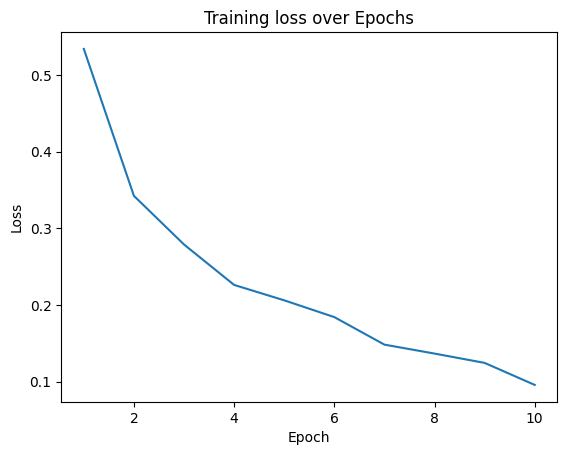

In [86]:
plt.plot(range(1, 11), train_losses, label="train")
plt.title( "Training loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

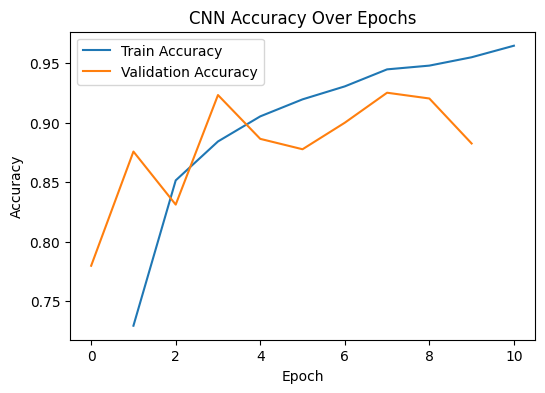

In [87]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Over Epochs")
plt.legend()
plt.show()

### incorporate dropout, since still unstable.

In [88]:
model = DropoutCNN().to(device)

train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0001,
    device=device
)

Epoch 1/10
  Train Loss: 0.4196 | Train Acc: 0.8029
  Val   Loss: 0.2973 | Val   Acc: 0.8758
Epoch 2/10
  Train Loss: 0.2803 | Train Acc: 0.8826
  Val   Loss: 0.2442 | Val   Acc: 0.8846
Epoch 3/10
  Train Loss: 0.2225 | Train Acc: 0.9088
  Val   Loss: 0.1840 | Val   Acc: 0.9263
Epoch 4/10
  Train Loss: 0.1821 | Train Acc: 0.9285
  Val   Loss: 0.3261 | Val   Acc: 0.8594
Epoch 5/10
  Train Loss: 0.1646 | Train Acc: 0.9416
  Val   Loss: 0.1850 | Val   Acc: 0.9263
Epoch 6/10
  Train Loss: 0.1397 | Train Acc: 0.9450
  Val   Loss: 0.1831 | Val   Acc: 0.9292
Epoch 7/10
  Train Loss: 0.1225 | Train Acc: 0.9517
  Val   Loss: 0.1980 | Val   Acc: 0.9234
Epoch 8/10
  Train Loss: 0.0936 | Train Acc: 0.9675
  Val   Loss: 0.3043 | Val   Acc: 0.8846
Epoch 9/10
  Train Loss: 0.0970 | Train Acc: 0.9665
  Val   Loss: 0.1822 | Val   Acc: 0.9321
Epoch 10/10
  Train Loss: 0.0803 | Train Acc: 0.9755
  Val   Loss: 0.1765 | Val   Acc: 0.9350


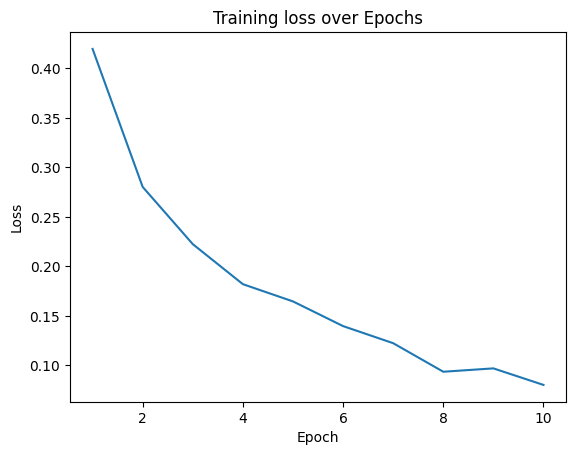

In [89]:
plt.plot(range(1, 11), train_losses, label="train")
plt.title( "Training loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

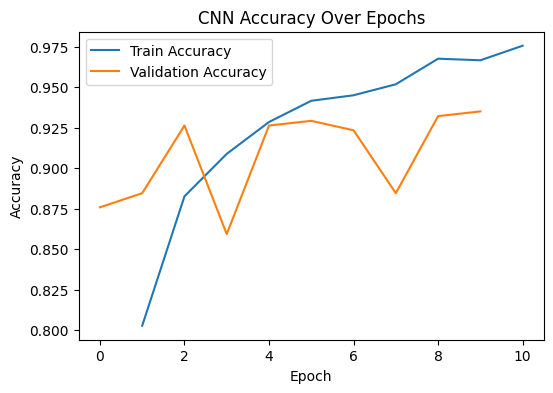

In [90]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Over Epochs")
plt.legend()
plt.show()

### analysis

will increase dropout. from 0.3 to 0.5

In [91]:
class DropoutCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(4, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 48 * 48, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [92]:
model = DropoutCNN().to(device)

train_losses, val_losses, train_accs, val_accs = train_model(
    model,
    train_loader,
    val_loader,
    epochs=10,
    lr=0.0001,
    device=device
)

Epoch 1/10
  Train Loss: 0.4683 | Train Acc: 0.7820
  Val   Loss: 0.2697 | Val   Acc: 0.9001
Epoch 2/10
  Train Loss: 0.2744 | Train Acc: 0.8880
  Val   Loss: 0.1961 | Val   Acc: 0.9224
Epoch 3/10
  Train Loss: 0.2386 | Train Acc: 0.9040
  Val   Loss: 0.2225 | Val   Acc: 0.9059
Epoch 4/10
  Train Loss: 0.2201 | Train Acc: 0.9110
  Val   Loss: 0.1649 | Val   Acc: 0.9360
Epoch 5/10
  Train Loss: 0.1767 | Train Acc: 0.9297
  Val   Loss: 0.1703 | Val   Acc: 0.9302
Epoch 6/10
  Train Loss: 0.1601 | Train Acc: 0.9430
  Val   Loss: 0.1769 | Val   Acc: 0.9292
Epoch 7/10
  Train Loss: 0.1423 | Train Acc: 0.9462
  Val   Loss: 0.1681 | Val   Acc: 0.9428
Epoch 8/10
  Train Loss: 0.1313 | Train Acc: 0.9510
  Val   Loss: 0.1483 | Val   Acc: 0.9437
Epoch 9/10
  Train Loss: 0.1405 | Train Acc: 0.9457
  Val   Loss: 0.2245 | Val   Acc: 0.9030
Epoch 10/10
  Train Loss: 0.1099 | Train Acc: 0.9583
  Val   Loss: 0.2386 | Val   Acc: 0.9079


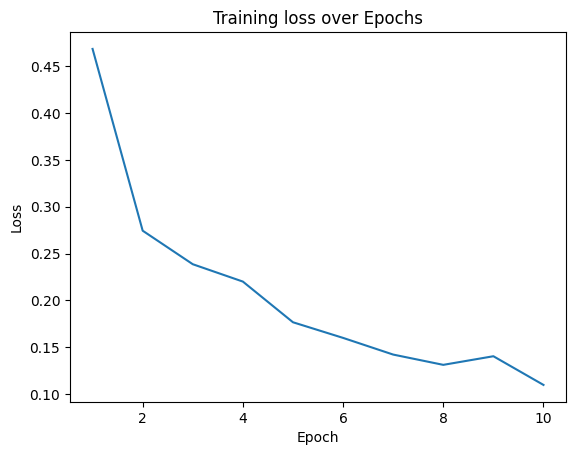

In [93]:
plt.plot(range(1, 11), train_losses, label="train")
plt.title( "Training loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

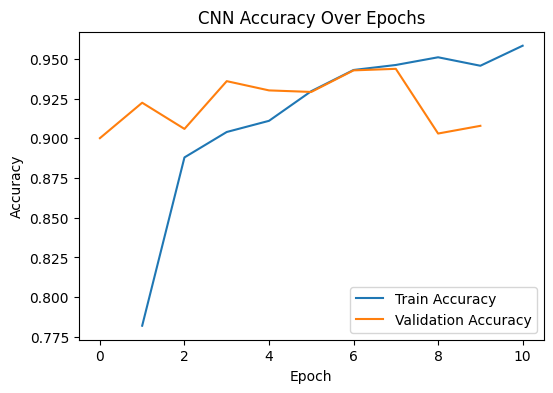

In [94]:
plt.figure(figsize=(6,4))
plt.plot(range(1, 11), train_accs, label="Train Accuracy")
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CNN Accuracy Over Epochs")
plt.legend()
plt.show()